# 03 - Backtest Baseline Inspection

This notebook inspects outputs from the baseline backtest. It reads generated CSV files and performs sanity checks on weights, active weights, turnover, and benchmark comparison tables.

## Portfolio Structure

The intended index-enhancement structure is:

$$ w_{i,t} = b_{i,t} + a_{i,t}$$

where `b_i,t` is the benchmark proxy weight, `a_i,t` is the active factor tilt, and `w_i,t` is the final long-only portfolio weight.

In [9]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"

def read_series_csv(path, parse_dates=True):
    frame = pd.read_csv(path, index_col=0, parse_dates=parse_dates)
    return frame.iloc[:, 0]

def read_required_csv(path, **kwargs):
    if not path.exists():
        raise FileNotFoundError(f"Run python main.py first. Missing: {path}")
    return pd.read_csv(path, **kwargs)

## Current Effective Configuration

The current baseline run uses 6-month no-skip momentum and the Version 1.3 risk-adjusted momentum alpha model. The portfolio remains benchmark-aware through the static market-cap proxy, with `max_weight: null` so mega-cap benchmark weights are not mechanically forced down by an absolute cap.

In [10]:
import yaml

with (PROJECT_ROOT / "config.yaml").open("r", encoding="utf-8") as file:
    config = yaml.safe_load(file) or {}

momentum_config = config.get("factors", {}).get("momentum", {})
alpha_config = config.get("alpha", {})
portfolio_config = config.get("portfolio", {})

current_config = pd.Series(
    {
        "momentum.lookback_days": momentum_config.get("lookback_days"),
        "momentum.skip_days": momentum_config.get("skip_days"),
        "alpha.model": alpha_config.get("model"),
        "alpha.lowvol_penalty_weight": alpha_config.get("lowvol_penalty_weight"),
        "portfolio.benchmark_weight_method": portfolio_config.get("benchmark_weight_method"),
        "portfolio.max_active_weight": portfolio_config.get("max_active_weight"),
        "portfolio.max_weight": portfolio_config.get("max_weight"),
    },
    name="value",
)
display(current_config.to_frame())

,value
momentum.lookback_days,126
momentum.skip_days,0
alpha.model,risk_adjusted_momentum
alpha.lowvol_penalty_weight,0.25
portfolio.benchmark_weight_method,market_cap_static
portfolio.max_active_weight,0.005
portfolio.max_weight,None


## Load Backtest Outputs

In [11]:
portfolio_returns = read_series_csv(DATA_PROCESSED / "portfolio_returns_net.csv")
benchmark_returns = read_series_csv(DATA_PROCESSED / "benchmark_returns.csv")
turnover = read_series_csv(DATA_PROCESSED / "turnover.csv")
weights = read_required_csv(DATA_PROCESSED / "weights.csv", index_col=0, parse_dates=True)

print(f"Portfolio return observations: {len(portfolio_returns)}")
print(f"Weight snapshots: {len(weights)}")
display(weights.tail())
display(turnover.tail())

Portfolio return observations: 2735
Weight snapshots: 131


,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,COIN,HOOD,CEG,GEHC,KVUE,VLTO,GEV,SOLV,SNDK,Q
2026-02-02,0.000633,0.056394,0.005359,0.001702,0.000650,0.001322,0.000803,0.003250,0.000886,0.000635,...,0.0,0.000280,0.000755,0.000455,0.000000,0.000140,0.003783,1.867963e-04,0.007291,NaN
2026-03-02,0.000373,0.056397,0.005240,0.001831,0.000599,0.000924,0.000688,0.003211,0.000637,0.000476,...,0.0,0.000000,0.001335,0.000506,0.000088,0.000068,0.004271,7.657818e-05,0.006429,NaN
2026-04-01,0.000327,0.056222,0.005104,0.001700,0.000698,0.001048,0.000647,0.003188,0.000927,0.000572,...,0.0,0.000000,0.001063,0.000347,0.000557,0.000064,0.004491,0.000000e+00,0.005009,NaN
2026-05-01,0.000005,0.055912,0.004932,0.001504,0.000686,0.000771,0.000613,0.003512,0.000833,0.000658,...,0.0,0.000000,0.000973,0.000000,0.000808,0.000034,0.004813,9.963446e-07,0.004951,0.000809
2026-06-01,0.000004,0.056079,0.004924,0.001289,0.000367,0.000781,0.000840,0.003479,0.001016,0.000836,...,0.0,0.000033,0.000892,0.000000,0.000542,0.000000,0.004628,0.000000e+00,0.005569,0.001357


2026-02-02    0.043419
2026-03-02    0.042723
2026-04-01    0.032555
2026-05-01    0.033832
2026-06-01    0.042367
Name: value, dtype: float64

## Weight Sanity Checks

In [12]:
weight_sums = weights.sum(axis=1)
min_weights = weights.min(axis=1)

checks = pd.DataFrame(
    {
        "weight_sum": weight_sums,
        "min_weight": min_weights,
        "max_weight": weights.max(axis=1),
        "nonzero_holdings": (weights > 0).sum(axis=1),
    }
)
display(checks.tail(10))

print(f"Latest weight sum: {weight_sums.iloc[-1]:.12f}")
print(f"Latest min weight: {min_weights.iloc[-1]:.12f}")
print(f"All latest weights non-negative: {(weights.iloc[-1] >= -1e-12).all()}")

,weight_sum,min_weight,max_weight,nonzero_holdings
2025-09-02,1.0,0.0,0.066933,416
2025-10-01,1.0,0.0,0.067328,412
2025-11-03,1.0,0.0,0.067193,418
2025-12-01,1.0,0.0,0.066718,416
2026-01-02,1.0,0.0,0.066639,410
2026-02-02,1.0,0.0,0.066364,423
2026-03-02,1.0,0.0,0.066417,424
2026-04-01,1.0,0.0,0.066460,425
2026-05-01,1.0,0.0,0.066152,417
2026-06-01,1.0,0.0,0.066452,412


Latest weight sum: 1.000000000000
Latest min weight: 0.000000000000
All latest weights non-negative: True


## Active Weights versus Static Market-Cap Proxy

If static market-cap weights are available, compare the latest portfolio weights to that proxy benchmark.

In [13]:
static_weights_path = DATA_PROCESSED / "static_market_cap_weights.csv"

if static_weights_path.exists():
    static_weights = pd.read_csv(static_weights_path, index_col=0).iloc[:, 0]
    latest_weights = weights.iloc[-1]
    aligned_index = latest_weights.index.union(static_weights.index)
    active_weights = latest_weights.reindex(aligned_index, fill_value=0.0) - static_weights.reindex(aligned_index, fill_value=0.0)
    active_weights = active_weights.sort_values(ascending=False)

    print(f"Active weight sum: {active_weights.sum():.12f}")
    print(f"Max absolute active weight: {active_weights.abs().max():.6f}")
    print("Top overweights")
    display(active_weights.head(15).to_frame("active_weight"))
    print("Top underweights")
    display(active_weights.tail(15).to_frame("active_weight"))
else:
    print(f"No static market-cap weights found at {static_weights_path}")

Active weight sum: 0.000000000000
Max absolute active weight: 0.002917
Top overweights


,active_weight
SNDK,0.002917
MU,0.001859
DELL,0.001775
WDC,0.001698
STX,0.001696
CIEN,0.001448
ON,0.001358
INTC,0.001323
LITE,0.001208
COHR,0.001079


Top underweights


,active_weight
COR,-0.000840
TSLA,-0.000874
ABT,-0.000884
HOOD,-0.000949
AVGO,-0.000969
META,-0.000982
NOW,-0.001002
BSX,-0.001205
AMZN,-0.001280
INTU,-0.001615


## Benchmark and Factor Variant Tables

In [14]:
benchmark_comparison = read_required_csv(REPORTS / "benchmark_comparison.csv")
factor_variants = read_required_csv(REPORTS / "factor_variant_sensitivity.csv")

display(benchmark_comparison)
display(factor_variants.sort_values("information_ratio", ascending=False))

,benchmark,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,hit_ratio,annualized_active_return,tracking_error,information_ratio
0,SPY,13.207742,0.277005,0.204964,1.296311,-0.329623,0.575137,0.117115,0.053218,2.200677
1,EqualWeightUniverse,13.207742,0.277005,0.204964,1.296311,-0.329623,0.575137,0.092988,0.087637,1.061064


,variant,factors,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,hit_ratio,annualized_active_return,tracking_error,information_ratio,average_turnover,annualized_turnover
0,momentum_only,momentum,13.829397,0.282053,0.207144,1.303912,-0.330816,0.573309,0.121516,0.055359,2.195046,0.048709,0.584504
3,momentum_lowvol,"momentum,lowvol",12.417922,0.270292,0.202635,1.282831,-0.329185,0.574771,0.111364,0.050862,2.189522,0.042565,0.510782
1,lowvol_only,lowvol,10.846929,0.255801,0.197415,1.253268,-0.329902,0.572212,0.098832,0.045260,2.183634,0.018228,0.218732
6,combined,"momentum,lowvol,reversal",12.143159,0.267873,0.203230,1.270282,-0.333374,0.573675,0.109577,0.050864,2.154296,0.046179,0.554150
4,momentum_reversal,"momentum,reversal",13.528225,0.279632,0.208423,1.288107,-0.336198,0.575503,0.119889,0.055890,2.145064,0.054108,0.649299
5,lowvol_reversal,"lowvol,reversal",10.843080,0.255764,0.200957,1.234539,-0.338261,0.573309,0.099507,0.047026,2.115993,0.067270,0.807237
2,reversal_only,reversal,12.637728,0.260717,0.208845,1.214508,-0.346613,0.566854,0.109662,0.055674,1.969702,0.120832,1.449982


## Version 1.1 Active Exposure Diagnostics

These diagnostics measure how far the realized portfolio weights move away from the benchmark proxy through time. They are especially useful in `market_cap_static` mode, where the benchmark proxy uses current market caps and therefore introduces look-ahead bias.

In [15]:
active_exposure = read_required_csv(REPORTS / "active_exposure_diagnostics.csv", index_col=0, parse_dates=True)
active_exposure_summary = read_required_csv(REPORTS / "active_exposure_summary.csv", index_col=0)

display(active_exposure_summary)

diagnostic_columns = [
    "gross_active_exposure",
    "active_share",
    "net_active_weight",
    "max_absolute_active_weight",
]
display(active_exposure.loc[:, diagnostic_columns].describe())

,value
average_gross_active_exposure,0.184523
average_active_share,0.092262
max_active_share,0.107989
average_max_absolute_active_weight,0.004371
max_absolute_active_weight,0.004990
average_abs_net_active_weight,0.000464


,gross_active_exposure,active_share,net_active_weight,max_absolute_active_weight
count,131.000000,131.000000,1.310000e+02,131.000000
mean,0.184523,0.092262,-4.639960e-04,0.004371
std,0.014799,0.007399,3.818791e-04,0.000804
min,0.159090,0.079545,-1.584634e-03,0.002135
25%,0.170791,0.085396,-7.052095e-04,0.004114
50%,0.182725,0.091362,-4.074282e-04,0.004990
75%,0.196770,0.098385,-1.875811e-04,0.004990
max,0.215978,0.107989,1.630640e-16,0.004990


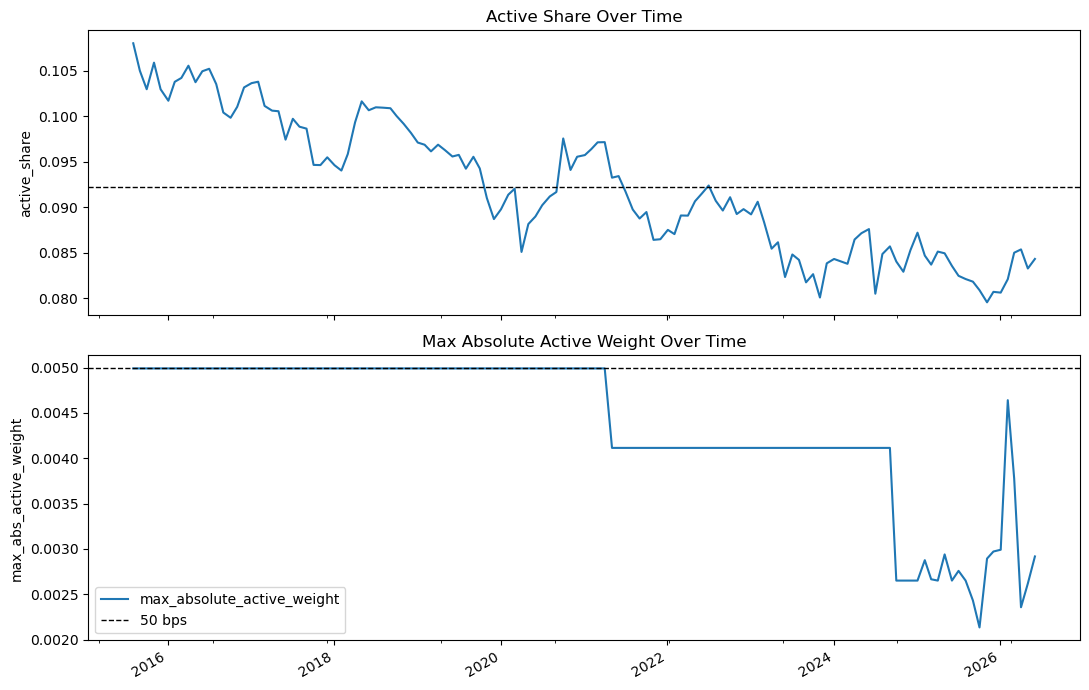

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
active_exposure["active_share"].plot(ax=axes[0], title="Active Share Over Time")
axes[0].set_ylabel("active_share")
axes[0].axhline(active_exposure["active_share"].mean(), color="black", linestyle="--", linewidth=1)

active_exposure["max_absolute_active_weight"].plot(ax=axes[1], title="Max Absolute Active Weight Over Time")
axes[1].set_ylabel("max_abs_active_weight")
axes[1].axhline(0.005, color="black", linestyle="--", linewidth=1, label="50 bps")
axes[1].legend()

plt.tight_layout()
plt.show()

The current active exposure summary shows average active share around 9.1%, while the maximum absolute active weight remains below 50 bps. This is consistent with an index-enhancement framework: the strategy takes small active tilts and stays close to the benchmark proxy. The benchmark proxy still uses current market caps in `market_cap_static` mode, so these diagnostics confirm portfolio closeness but do not remove look-ahead bias.

## Interpretation Warning

The static market-cap proxy is not point-in-time. It makes the portfolio construction conceptually closer to S&P 500 index enhancement, but applying current market caps historically introduces look-ahead bias. Strong results in this mode should be interpreted as framework demonstration, not tradable historical evidence.